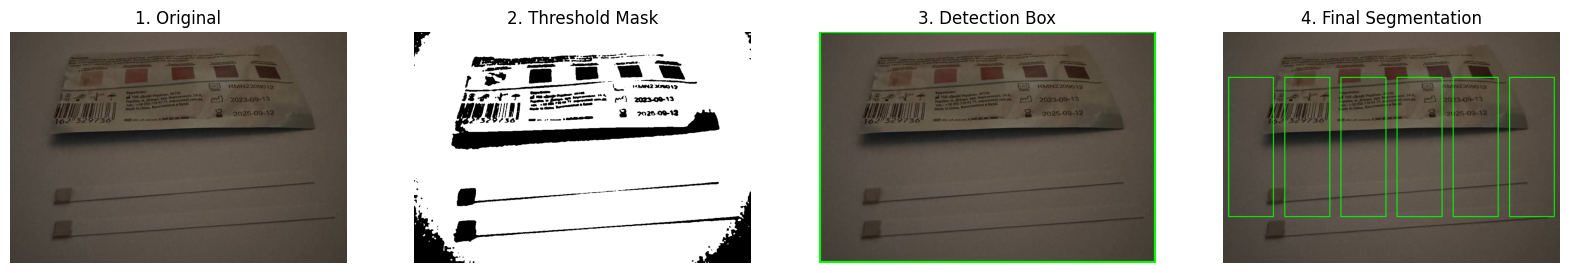

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ---

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def detect_reagent_patches(warped_img):
    """
    Реально ищет координаты цветных квадратов на белой полоске
    """
    # 1. Переводим в Grayscale
    gray = cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY)
    
    # 2. Инвертируем и применяем порог. 
    # Белая подложка станет черной, а темные реагенты — светлыми.
    # Можно использовать Adaptive Threshold, если освещение неравномерное
    thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)[1]
    
    # 3. Ищем контуры внутри полоски
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    found_coords = []
    h_strip, w_strip = warped_img.shape[:2]
    
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Фильтруем: квадрат не должен быть слишком огромным или слишком крошечным
        # И он должен быть примерно квадратным (w/h около 1)
        aspect_ratio = float(w)/h
        if 0.8 < aspect_ratio < 1.2 and (h_strip * 0.3 < h < h_strip * 0.9):
            found_coords.append((x, y, x + w, y + h))
    
    # Сортируем координаты слева направо (по X), чтобы не перепутать порядок
    found_coords = sorted(found_coords, key=lambda x: x[0])
    
    return found_coords

def show_steps(images, titles):
    plt.figure(figsize=(20, 10))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        if len(images[i].shape) == 2: # Если ЧБ
            plt.imshow(images[i], cmap='gray')
        else: # Если цветное (конвертируем из BGR в RGB для корректного цвета)
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# --- 2. ОСНОВНОЙ ПРОЦЕСС ---

# Укажите путь к вашему фото здесь
img_path = 'кетоны/свет0-вид под углом/full.jpg' 
img = cv2.imread(img_path)

if img is None:
    print("Ошибка: не удалось загрузить картинку. Проверьте путь!")
else:
    # Шаг 1: Предобработка
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Шаг 2: Поиск полоски
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    strip_cnt = max(contours, key=cv2.contourArea)
    
    # Получаем 4 угла
    rect_min = cv2.minAreaRect(strip_cnt)
    box = cv2.boxPoints(rect_min)
    box = box.astype(int)

    # Шаг 3: Выпрямление (Warp)
    rect_pts = order_points(box.astype("float32"))
    (tl, tr, br, bl) = rect_pts
    width = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
    height = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))
    
    dst = np.array([[0, 0], [width-1, 0], [width-1, height-1], [0, height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect_pts, dst)
    warped = cv2.warpPerspective(img, M, (width, height))
    
    # Если полоска вертикальная — разворачиваем
    if height > width:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

    # Шаг 4: Оконтуривание квадратиков внутри полоски
    h_w, w_w = warped.shape[:2]
    warped_with_grid = warped.copy()
    num_patches = 6
    for i in range(num_patches):
        x_s = int(i * (w_w/num_patches) + (w_w/num_patches * 0.1))
        x_e = int((i+1) * (w_w/num_patches) - (w_w/num_patches * 0.1))
        cv2.rectangle(warped_with_grid, (x_s, int(h_w*0.2)), (x_e, int(h_w*0.8)), (0, 255, 0), 2)

    # --- 3. ВИЗУАЛИЗАЦИЯ ВСЕХ ЭТАПОВ ---
    
    # Рисуем найденную рамку на оригинале для наглядности
    img_detection = img.copy()
    cv2.drawContours(img_detection, [box], 0, (0, 255, 0), 10)

    show_steps(
        [img, thresh, img_detection, warped_with_grid], 
        ["1. Original", "2. Threshold Mask", "3. Detection Box", "4. Final Segmentation"]
    )